In [1]:
#Notebook Author: Trenton McKinney
#Course: DataCamp: Fraud Detection in Python
#This notebook was created as a reproducible reference.

#This exericse 6.2 is slighlty modified from the original

<h3>Exercise 6.2, Fraud detection using text</h3>

In this task, you'll be analyzing text data consisting of emails sent by Enron employees. The Enron scandal is well-known for its fraudulent activities. Enron employees engaged in deceptive practices to conceal the company's poor financial status, artificially inflating its stock price. They also took advantage of this situation by selling their own stock options. However, when the truth about Enron's financial situation was revealed, investors suffered significant losses. Your objective is to identify all emails that contain certain key phrases, such as "sell Enron stock".

You don't need to code anything. Simply choose words or terms that could indicate fraudulent activities (cell 9) and answer 3 questions in the end of the exercise. 


In [2]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')


In [3]:
#! pip install pyLDAvis
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
from pprint import pprint as pp
import csv
from pathlib import Path
import seaborn as sns
from itertools import product
import string

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import nltk
from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer

nltk.download('stopwords')
stop = set(stopwords.words('english'))
stop

nltk.download('wordnet')
#nltk.download('omw-1.4')

import gensim
from gensim import corpora

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Teemu\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Teemu\AppData\Roaming\nltk_data...


In [4]:
pd.set_option('display.max_columns', 700)
pd.set_option('display.max_rows', 400)
pd.set_option('display.min_rows', 10)
pd.set_option('display.expand_frame_repr', True)

In [5]:
enron_emails_clean_file =  'enron_emails_clean.csv'


In [6]:
df = pd.read_csv(enron_emails_clean_file)

In [7]:
mask = df['clean_content'].str.contains('sell enron stock', na=False)

In [8]:
# Select the data from df using the mask
df[mask]

,Message-ID,From,To,Date,content,clean_content
154,<6336501.1075841154311.JavaMail.evans@thyme>,('sarah.palmer@enron.com'),('sarah.palmer@enron.com'),2002-02-01 14:53:35,\nJoint Venture: A 1997 Enron Meeting Belies O...,joint venture enron meeting belies officers cl...


Choose 3-6 words or terms that could be indicative of fraud. For example, 'sell enron stock'. 

In [194]:
# Create a list of terms to search for
#searchfor = ['delete', 'this', 'message']
# searchfor = ['stock', 'going', 'down']
#searchfor = ['heard', 'from', 'inside']
#searchfor = ['pull', 'the', 'plug']
# searchfor = ['sell', 'before', 'drop']
#searchfor = ['sell', 'enron', 'stock']
# searchfor = ['stock', 'will', 'crash']
searchfor = ['sell', 'down', 'bonus', 'profit', 'stock']


# Filter cleaned emails on searchfor list and select from df 
filtered_emails = df[df.clean_content.str.contains('|'.join(searchfor), na=False)]
filtered_emails.head()

,Message-ID,From,To,Date,content,clean_content,flag
0,<8345058.1075840404046.JavaMail.evans@thyme>,('advdfeedback@investools.com'),('advdfeedback@investools.com'),2002-01-29 23:20:55,INVESTools Advisory\nA Free Digest of Trusted ...,investools advisory free digest trusted invest...,1
1,<1512159.1075863666797.JavaMail.evans@thyme>,('richard.sanders@enron.com'),('richard.sanders@enron.com'),2000-09-20 19:07:00,----- Forwarded by Richard B Sanders/HOU/ECT o...,forwarded richard b sanders hou ect pm justin ...,1
2,<26118676.1075862176383.JavaMail.evans@thyme>,('m..love@enron.com'),('m..love@enron.com'),2001-10-30 16:15:17,hey you are not wearing your target purple shi...,hey wearing target purple shirt today mine wan...,1
3,<10369289.1075860831062.JavaMail.evans@thyme>,('leslie.milosevich@kp.org'),('leslie.milosevich@kp.org'),2002-01-30 17:54:18,Leslie Milosevich\n1042 Santa Clara Avenue\nAl...,leslie milosevich santa clara avenue alameda c...,1
4,<26728895.1075860815046.JavaMail.evans@thyme>,('rtwait@graphicaljazz.com'),('rtwait@graphicaljazz.com'),2002-01-30 19:36:01,"Rini Twait\n1010 E 5th Ave\nLongmont, CO 80501...",rini twait e th ave longmont co rtwait graphic...,1


In [195]:
# Create flag variable where the emails match the searchfor terms
df['flag'] = np.where((df['clean_content'].str.contains('|'.join(searchfor)) == True), 1, 0)

# Count the values of the flag variable
count = df['flag'].value_counts()
print(count)

flag
0    1508
1     582
Name: count, dtype: int64


In [196]:
# Define stopwords to exclude
stop = set(stopwords.words('english'))


In [197]:
# add here words that you would like to exclude from the analysis: 

stop.update(( "http", "com", "e", "pm", "mr", "www", "net", "td", "img", "href", "nbsp", "u", "wj", "cc", "hou", "tr",
             "aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa", "also", "na", "ee", "sp", "ne", "se", "enron",
             "u", "sat", "would", "mailto", "bakernet", "company", "subject", "message", "sent", "ect", "height", "weight", "j"))


In [198]:
# Define punctuations to exclude and lemmatizer
exclude = set(string.punctuation)

In [199]:
# Import the lemmatizer from nltk
lemma = WordNetLemmatizer()

def clean(text, stop):
    text = str(text).rstrip()
    stop_free = " ".join([i for i in text.lower().split() if((i not in stop) and (not i.isdigit()))])
    punc_free = ''.join(i for i in stop_free if i not in exclude)
    normalized = " ".join(lemma.lemmatize(i) for i in punc_free.split())      
    return normalized

In [200]:
# Clean the emails in df and print results
text_clean=[]
for text in df['clean_content']:
    text_clean.append(clean(text, stop).split())    

In [201]:
# check hat the cleaned words look relevant
text_clean[0][:10]

['investools',
 'advisory',
 'free',
 'digest',
 'trusted',
 'investment',
 'advice',
 'unsubscribe',
 'free',
 'newsletter']

In [202]:
# Define the dictionary
dictionary = corpora.Dictionary(text_clean)

# Define the corpus 
corpus = [dictionary.doc2bow(text) for text in text_clean]

In [203]:
print(dictionary)

Dictionary<33989 unique tokens: ['account', 'accurate', 'acquiring', 'acre', 'address']...>


In [204]:
corpus[0][:10]

[(0, 2),
 (1, 1),
 (2, 1),
 (3, 1),
 (4, 1),
 (5, 6),
 (6, 1),
 (7, 2),
 (8, 4),
 (9, 1)]

In [205]:
# Define the LDA model
ldamodel = gensim.models.ldamodel.LdaModel(corpus, num_topics=5, id2word=dictionary, passes=5)

# Save the topics and top 5 words
topics = ldamodel.print_topics(num_words=5)

# Print the results
for topic in topics:
    print(topic)

(0, '0.010*"energy" + 0.010*"image" + 0.009*"employee" + 0.006*"million" + 0.006*"doc"')
(1, '0.017*"image" + 0.004*"said" + 0.004*"wscc" + 0.004*"see" + 0.004*"click"')
(2, '0.045*"money" + 0.039*"width" + 0.028*"class" + 0.024*"table" + 0.022*"br"')
(3, '0.010*"market" + 0.007*"service" + 0.007*"please" + 0.006*"conference" + 0.006*"time"')
(4, '0.008*"original" + 0.007*"development" + 0.007*"please" + 0.007*"thanks" + 0.007*"corp"')


Topic 0: 0.010*"energy" + 0.010*"image" + 0.009*"employee" + 0.006*"million" + 0.006*"doc"


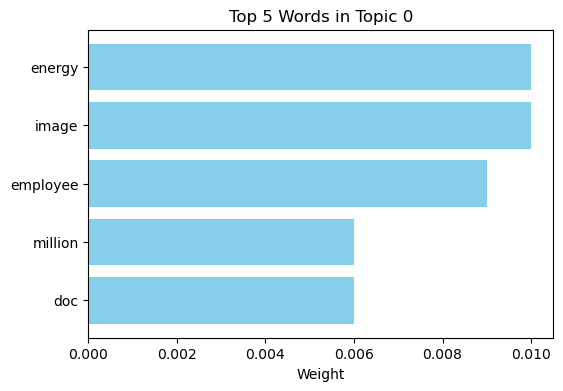

Topic 1: 0.017*"image" + 0.004*"said" + 0.004*"wscc" + 0.004*"see" + 0.004*"click"


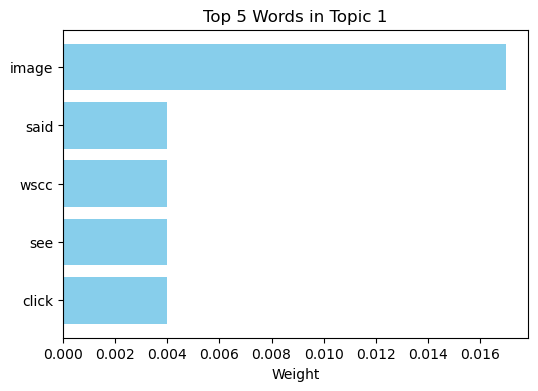

Topic 2: 0.045*"money" + 0.039*"width" + 0.028*"class" + 0.024*"table" + 0.022*"br"


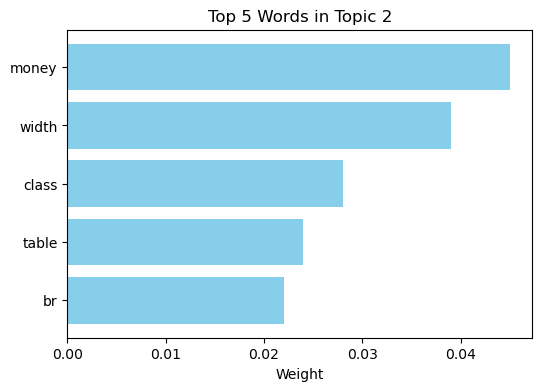

Topic 3: 0.010*"market" + 0.007*"service" + 0.007*"please" + 0.006*"conference" + 0.006*"time"


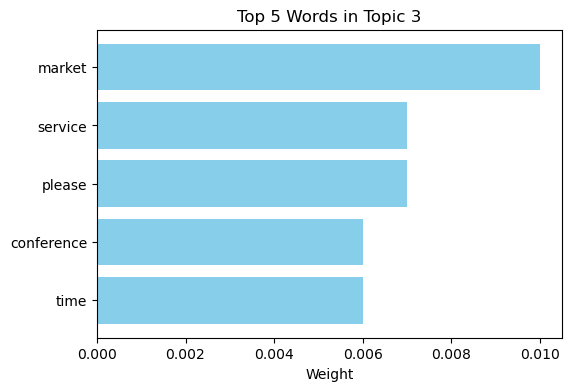

Topic 4: 0.008*"original" + 0.007*"development" + 0.007*"please" + 0.007*"thanks" + 0.007*"corp"


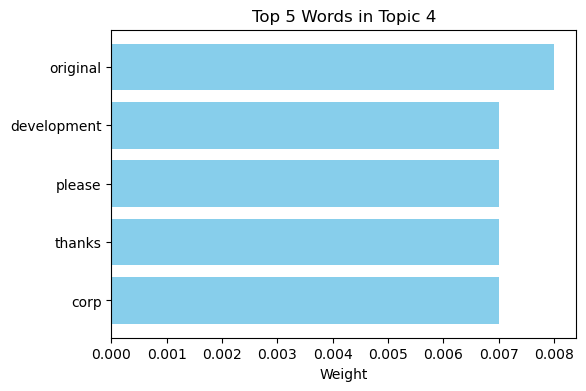

In [206]:
# Print and visualize the results
for idx, topic in topics:
    print(f"Topic {idx}: {topic}")
    words = [word.split('*')[1].strip('" ') for word in topic.split(' + ')]
    weights = [float(word.split('*')[0]) for word in topic.split(' + ')]
    plt.figure(figsize=(6, 4))  # Adjust the figure size here
    plt.barh(words, weights, color='skyblue')
    plt.xlabel('Weight')
    plt.title(f'Top 5 Words in Topic {idx}')
    plt.gca().invert_yaxis()
    plt.show()

If you lack labels for fraudulent behavior, you can still identify potential fraudulent topics by examining the frequency of suspicious words within topics. Look for topics that appear to describe activities related to fraud, such as discussions about stock bonuses, selling stock, stock prices, and possibly mentions of accounting or financial weaknesses. Identifying suspicious topics may require some prior knowledge about fraudulent behavior. Once you've identified a suspicious topic, you can flag all instances that have a high probability for this topic, indicating potential involvement in fraudulent activities.by McKinney: Using your LDA model results for fraud detection.

In [207]:
import pyLDAvis.gensim  
lda_display = pyLDAvis.gensim.prepare(ldamodel, corpus, dictionary, sort_topics=False)

C:\Users\Teemu\AppData\Roaming\Python\Python312\site-packages\joblib\_utils.py:38: DeprecationWarning: ast.Num is deprecated and will be removed in Python 3.14; use ast.Constant instead
  if isinstance(node, ast.Num):  # <number>
C:\Users\Teemu\AppData\Roaming\Python\Python312\site-packages\joblib\_utils.py:38: DeprecationWarning: ast.Num is deprecated and will be removed in Python 3.14; use ast.Constant instead
  if isinstance(node, ast.Num):  # <number>
C:\Users\Teemu\AppData\Roaming\Python\Python312\site-packages\joblib\_utils.py:39: DeprecationWarning: Attribute n is deprecated and will be removed in Python 3.14; use value instead
  return node.n
C:\Users\Teemu\AppData\Roaming\Python\Python312\site-packages\joblib\_utils.py:38: DeprecationWarning: ast.Num is deprecated and will be removed in Python 3.14; use ast.Constant instead
  if isinstance(node, ast.Num):  # <number>
C:\Users\Teemu\AppData\Roaming\Python\Python312\site-packages\joblib\_utils.py:39: DeprecationWarning: Attribut

In [208]:
pyLDAvis.display(lda_display)

Click on each circle to see more details about that specific topic on the right panel.

In the visualization, each circle on the left side represents a different topic. The size of each circle indicates how prominent that topic is overall. You can  The words shown in the right panel are the most significant keywords that define the selected topic.

A well-performing topic model will have relatively large circles that do not overlap much, spread out across the chart. On the other hand, a model with too many topics may result in many small circles that overlap or are clustered together in one area.

In the example provided, there is a slight overlap between topics 2 and 3, suggesting that there might be one topic too many in the model. This overlap indicates that these two topics share some common keywords and could potentially be merged into a single topic to improve the clarity and effectiveness of the model.by McKinney: Each bubble on the left-hand side represents a topic.
The larger the bubble, the more prevalent that topic is.
Click on each topic to get the details per topic in the right panel.
The words are the most important keywords that form the selected topic.
A good topic model will have fairly big, non-overlapping bubbles, scattered throughout the chart.

A model with too many topics, will typically have many overlaps, or small sized bubbles, clustered in one region. 

 Finding fraudsters based on topic

In [96]:
def get_topic_details(ldamodel, corpus):
    topic_details = []
    for i, row in enumerate(ldamodel[corpus]):
        row = sorted(row, key=lambda x: (x[1]), reverse=True)
        for j, (topic_num, prop_topic) in enumerate(row):
            if j == 0:  # => dominant topic
                wp = ldamodel.show_topic(topic_num)
                topic_details.append({'Dominant_Topic': topic_num, '% Score': prop_topic})
    topic_details_df = pd.DataFrame(topic_details)
    return topic_details_df

In [97]:
# Run get_topic_details function and check the results
topic_details_df = get_topic_details(ldamodel, corpus)

In [98]:
topic_details_df.head()

,Dominant_Topic,% Score
0,3,0.947285
1,0,0.822224
2,0,0.881008
3,3,0.993464
4,3,0.993439


In [99]:
# Add original text to topic details in a dataframe
contents = pd.DataFrame({'Original text': text_clean})
topic_details = pd.concat([get_topic_details(ldamodel, corpus), contents], axis=1)

In [100]:
topic_details.sort_values(by=['% Score'], ascending=False).head(10).head()

,Dominant_Topic,% Score,Original text
849,1,0.999876,"[original, message, received, thu, aug, cdt, e..."
2081,2,0.999667,"[unsubscribe, mailing, please, go, http, www, ..."
240,3,0.998824,"[wsj, heard, street, enron, ex, ceo, made, bet..."
1138,0,0.998807,"[greg, great, time, million, club, lavo, dave,..."
1928,0,0.998736,"[uh, yeah, whole, bunch, single, one, squishy,..."


In [101]:
topic_details.sort_values(by=['% Score'], ascending=False).head(10).tail()

,Dominant_Topic,% Score,Original text
974,0,0.998472,"[forwarded, vince, j, kaminski, hou, ect, pm, ..."
1139,0,0.998376,"[shiela, following, call, could, please, provi..."
2014,1,0.998323,"[forwarded, chris, h, foster, hou, ect, pm, en..."
1769,0,0.998268,"[please, make, sure, know, asst, forwarded, je..."
2088,3,0.998205,"[transmission, expansion, system, transition, ..."


In [102]:
# Create flag for text highest associated with topic 3
topic_details['flag'] = np.where((topic_details['Dominant_Topic'] == 3.0), 1, 0)

In [103]:
topic_details_1 = topic_details[topic_details.flag == 1]

In [104]:
#topic_details_1.sort_values(by=['% Score'], ascending=False).head(10)
print(topic_details['Dominant_Topic'].unique())

[3 0 4 1 2]


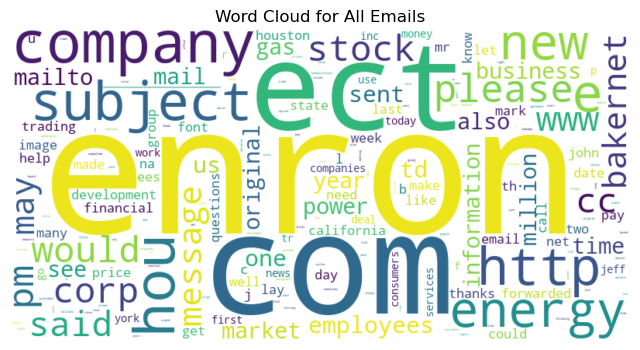

In [105]:
from wordcloud import WordCloud
from collections import Counter  # Import the Counter class

# Replace NaN values with empty strings in the 'clean_content' column
df['clean_content'] = df['clean_content'].fillna('')

# Combine all cleaned text from emails
all_text = ' '.join(df['clean_content'])

# Tokenize the text into words
words = all_text.split()

# Count the frequency of each word
word_counts = Counter(words)

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)

# Display the word cloud
plt.figure(figsize=(8, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for All Emails')
plt.show()

In [106]:
 # Print the results
print("Topic Details:")
print(topic_details_df.head())
print("\nFiltered Emails:")
print(filtered_emails.head())
print("\nTop Topic Details with Flag:")
print(topic_details_1.sort_values(by=['% Score'], ascending=False).head(10))


Topic Details:
   Dominant_Topic   % Score
0               3  0.947285
1               0  0.822224
2               0  0.881008
3               3  0.993464
4               3  0.993439

Filtered Emails:
                                      Message-ID  \
0   <8345058.1075840404046.JavaMail.evans@thyme>   
1   <1512159.1075863666797.JavaMail.evans@thyme>   
3  <10369289.1075860831062.JavaMail.evans@thyme>   
4  <26728895.1075860815046.JavaMail.evans@thyme>   
5  <24716667.1075860824904.JavaMail.evans@thyme>   

                              From                               To  \
0  ('advdfeedback@investools.com')  ('advdfeedback@investools.com')   
1    ('richard.sanders@enron.com')    ('richard.sanders@enron.com')   
3     ('leslie.milosevich@kp.org')     ('leslie.milosevich@kp.org')   
4     ('rtwait@graphicaljazz.com')     ('rtwait@graphicaljazz.com')   
5  ('guelaguetza@club.lemonde.fr')  ('guelaguetza@club.lemonde.fr')   

                  Date                                     

QUESTIONS: 

1. What were the main steps? What NLP-tools did we use to analyse the data?

2. Looking at the results, you can see that there are non-informative words (https etc.) After the cell '# Define stopwords to exclude', add your own list of words to be excluded.

3. Analyze the results. How many flags? How many filtered topics? What could be the dominant topics, based on the words related to them? What does 'Top Topic Details with Flag' tell you? To improve the results, could you still add some words or terms to search for?

